# `subcell` capability tour — iGluSnFR4f Bergamo dataset

A hands-on pass over what `subcell` does, run on
`scan_00001_20240924_110500_mouse750098.tif`, written to answer two questions before
wiring this package into `mbo_utilities` as a pipeline:

1. **What does data have to look like going in?**
2. **What comes out, how long does it take, and how big is it?**

`subcell` is a Python port of a MATLAB pipeline for **synaptic-resolution** glutamate
imaging on a Bergamo two-photon scope. It is not a somatic segmentation package — it
finds sub-micron sources (spines / boutons) in a small, very fast field of view and
solves a constrained NMF for their traces.

Two stages, both writing into one Zarr store:

```
ScanImage TIFF(s)
      |
      v   TrialTable            one entry per trial (per file)
   +----------------------------------------------------------------------+
   | STAGE 1  registration      subcell.registration.bergamo              |
   |  flyback crop -> baseline subtract -> clustered template ->          |
   |  FFT/DFT subpixel alignment on 8x-downsampled frames ->              |
   |  PCHIP upsample of motion back to full rate                          |
   +----------------------------------------------------------------------+
      |   experiment.zarr/trials/trial_NNN/
      |     registered_ds     8x temporally downsampled  -> source detection
      |     registered_raw    full frame rate            -> NMF  (optional, large)
      |     alignment/        motion_r/c, rec_neg_err    -> QC + motion censoring
      v
   +----------------------------------------------------------------------+
   | STAGE 2  extraction        subcell.pipeline.runner.run_extraction    |
   |  1 localize_sources     matched filter + DoG + spatiotemporal NMS    |
   |  2 align_trials_cross   put every trial in one frame, reject bad     |
   |  3 select_sources       peak picking + density cap + pixel disks     |
   |  4 extract_trial        per-source constrained NMF at full rate      |
   +----------------------------------------------------------------------+
      |   experiment.zarr/
      |     summary/          mean + activity image, source locations, sel_pix
      |     trials/*/extraction/  footprints, events, denoised, ls, F0, SNR
```

In [4]:
import logging
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.0,
    "figure.dpi": 130,
})

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-7s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
# The NMF solver logs one line per subproblem; quiet it down.
logging.getLogger("subcell.extraction.extract_trial").setLevel(logging.WARNING)

# ---------------------------------------------------------------- knobs ----
TIFF = Path(r"C:\Users\loson\data\adrian\iGluSnFR4f_example_data\scan_00001_20240924_110500_mouse750098.tif")
DATA_DIR = TIFF.parent
OUT_DIR = DATA_DIR / "subcell_demo"          # ~1.7 GB for the default subset; safe to delete
ZARR = OUT_DIR / "experiment.zarr"

N_FRAMES = 40_000      # frames of the recording to use; None = the whole file
DEVICE = "cpu"         # "cpu" | "cuda" | "auto"  (CPU is fine at this FOV, see section 7)
REMOVE_LINES = 4       # flyback lines cropped off the top of every frame
DS_TIME = 3            # temporal downsample exponent for registration: 2**3 = 8x

OUT_DIR.mkdir(parents=True, exist_ok=True)
assert TIFF.exists(), TIFF

import subcell
print("subcell", subcell.__version__, "from", Path(subcell.__file__).parent)
print("output ->", ZARR)

subcell 0.1.0 from C:\Users\loson\repos\subcell\subcell
output -> C:\Users\loson\data\adrian\iGluSnFR4f_example_data\subcell_demo\experiment.zarr


---
## 1. The input contract

`subcell` reads **ScanImage multi-page TIFFs**, one file per trial. Everything else it
needs (frame rate, channel count, geometry) is pulled out of the embedded ScanImage
metadata — there is no sidecar file, and the only manual override is
`RegistrationConfig.frame_rate`, which is a fallback rather than a setting.

| Requirement | Where it is enforced | What happens if violated |
|---|---|---|
| BigTIFF (version 43) | `_parse_bigtiff_header` | falls back to `tifffile.asarray()` — reads the **whole file into RAM** |
| Uncompressed | same | same fallback |
| 16-bit samples | same | same fallback |
| Constant page stride (plain ScanImage output, not re-saved) | `_verify_page_stride` | same fallback |
| Channels **interleaved page-by-page**, `[t0c0, t0c1, t1c0, ...]` | `reshape_interleaved` | channels get scrambled, silently |
| Single Z plane | `array_trial_source` | `ValueError` on the array path; unchecked on the TIFF path |
| `SI.hChannels.channelSave` present | `parse_scanimage_metadata` | channel count defaults to 1 |
| `SI.hRoiManager.scanFramePeriod` present | same | frame time falls back to `config.frame_rate`, then a hard-coded 2.3 ms |

The first four are a **performance** contract, not a correctness one: when they hold,
`MmapTiffReader` builds a zero-copy `(rows, cols, channels, frames)` strided view over an
`np.memmap` and opens a 5 GB file in milliseconds. When they don't, subcell still works but
materialises the entire recording.

In [2]:
from subcell.io.tiff_reader import MmapTiffReader, _parse_bigtiff_header

layout = _parse_bigtiff_header(TIFF)
print("--- raw BigTIFF layout (what the fast path keys on) ---")
for k in ("page0_offset", "page_stride", "rows", "cols", "num_channels", "file_size"):
    print(f"  {k:<14} {layout[k]:,}")

t0 = time.perf_counter()
reader = MmapTiffReader(TIFF, remove_lines=0)   # keep flyback for now so we can look at it
open_s = time.perf_counter() - t0
Ad = reader.data          # zero-copy strided view, (rows, cols, channels, frames)
meta = reader.metadata
n_ch = meta.num_channels

print(f"\n--- opened in {open_s*1000:.1f} ms (zero copy) ---")
print(f"  file size          {TIFF.stat().st_size/1e9:.2f} GB")
print(f"  Ad                 {Ad.shape}  {Ad.dtype}   (rows, cols, channels, frames)")
print(f"  ScanImage channels {meta.channel_save}  -> subcell channel 1..{n_ch}")
print(f"  frame rate         {meta.frame_rate:.3f} Hz  ({meta.frame_time*1e3:.3f} ms/frame)")
print(f"  duration           {meta.num_frames*meta.frame_time:.1f} s")
print(f"  FOV width          {meta.pixel_scale:.1f} um  -> {meta.pixel_scale/meta.num_cols*1e3:.0f} nm/px across")
print(f"\n  after {REMOVE_LINES} flyback lines: {Ad.shape[0]-REMOVE_LINES} x {Ad.shape[1]} px")

10:52:51 INFO    subcell.io.tiff_reader: Opening mmap TIFF: scan_00001_20240924_110500_mouse750098.tif


10:52:51 INFO    subcell.io.tiff_reader: Mmap opened: 50 x 128, 2 ch, 168533 frames (page_stride=15184, offset=22780)


--- raw BigTIFF layout (what the fast path keys on) ---
  page0_offset   22,780
  page_stride    15,184
  rows           50
  cols           128
  num_channels   2
  file_size      5,118,030,540

--- opened in 2.4 ms (zero copy) ---
  file size          5.12 GB
  Ad                 (50, 128, 2, 168533)  int16   (rows, cols, channels, frames)
  ScanImage channels [2, 4]  -> subcell channel 1..2
  frame rate         429.925 Hz  (2.326 ms/frame)
  duration           392.0 s
  FOV width          37.3 um  -> 291 nm/px across

  after 4 flyback lines: 46 x 128 px


### Channel indexing is a foot-gun

ScanImage saved channels **2 and 4**. `ExtractionConfig.activity_channel` is **1-indexed into
the saved order**, not the ScanImage number. On this file:

* `activity_channel=1` -> ScanImage channel 2
* `activity_channel=2` -> ScanImage channel 4

Nothing in the package cross-checks the two numbering schemes. Both channels are shown below;
the choice is made further down from the data itself rather than from the label.

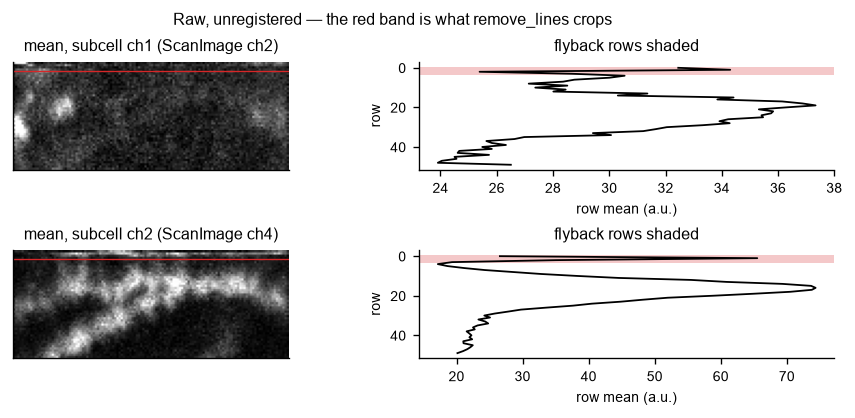

In [3]:
# Sparse temporal sample so this stays cheap on a 5 GB file.
sample = Ad[:, :, :, ::500].astype(np.float32)
mean_raw = sample.mean(axis=3)

fig, axes = plt.subplots(n_ch, 2, figsize=(7.0, 1.55 * n_ch), constrained_layout=True)
for ch in range(n_ch):
    im = mean_raw[:, :, ch]
    ax = axes[ch, 0]
    ax.imshow(im, cmap="gray", vmin=np.percentile(im, 1), vmax=np.percentile(im, 99.5))
    ax.axhline(REMOVE_LINES - 0.5, color="tab:red", lw=0.75)
    ax.set_title(f"mean, subcell ch{ch+1} (ScanImage ch{meta.channel_save[ch]})")
    ax.set_xticks([])
    ax.set_yticks([])

    ax = axes[ch, 1]
    ax.plot(im.mean(axis=1), np.arange(im.shape[0]), color="k")
    ax.axhspan(-0.5, REMOVE_LINES - 0.5, color="tab:red", alpha=0.25, lw=0)
    ax.invert_yaxis()
    ax.set_xlabel("row mean (a.u.)")
    ax.set_ylabel("row")
    ax.set_title("flyback rows shaded")
fig.suptitle("Raw, unregistered — the red band is what remove_lines crops", fontsize=9)
plt.show()

del sample, mean_raw

---
## 2. Three ways to get data in

| route | entry point | when to use |
|---|---|---|
| **A. directory of TIFFs** | `TrialTable.from_directory(dir)` -> `register_bergamo(tt, ...)` | the CLI path (`subcell run <dir>`); one TIFF per trial, files matching `REGISTERED`/`FIGURE` are skipped |
| **B. pre-loaded array** | `register_bergamo(..., raw_data=pages, metadata=meta)` | you already have the pages in RAM. `pages` is `(rows, cols, frames*channels)`, **channel-interleaved, flyback still attached** — `config.remove_lines` is applied for you. Single-trial tables only. |
| **C. `mbo_utilities` LazyArray** | `array_trial_source(arr)` -> `register_bergamo(..., source=src)` | **the integration route.** Takes a 5-D `TCZYX` array, splits it on `frames_per_file` metadata, and reads one trial at a time. |

Route C is what `subcell.mbo.task_subcell` already uses, and what the `mbo_utilities.pipelines`
entry point wires into the studio dropdown. Two things about it are worth knowing before
building on it:

* **`config.remove_lines` is ignored on route C.** `_register_single_trial` short-circuits the
  interleave reshape when `frames=` is supplied, and the flyback crop lives inside that reshape.
  Whatever the array hands over is registered as-is.
* **Trial boundaries come only from `frames_per_file`.** One file means one trial, and
  cross-trial alignment then has nothing to align.

In [4]:
from mbo_utilities import imread
from subcell.io.lazy_array import array_trial_source, trial_boundaries, trial_table_from_array

lazy = imread(TIFF)
print("mbo_utilities LazyArray")
print(f"  type            {type(lazy).__name__}")
print(f"  shape           {tuple(lazy.shape)}   (T, C, Z, Y, X)")
print(f"  dtype           {lazy.dtype}")
print(f"  fs              {lazy.metadata['fs']} Hz")
print(f"  frames_per_file {lazy.metadata['frames_per_file']}")
print(f"  flyback lines   {lazy.metadata['num_fly_to_lines']}  <- mbo's own count, NOT applied to the array")

print(f"\n  trial_boundaries       -> {trial_boundaries(lazy)}")
src = array_trial_source(lazy)
print(f"  array_trial_source     -> {src.n_trials} trial(s), {src.metadata.num_rows} x "
      f"{src.metadata.num_cols}, {src.metadata.num_channels} ch @ {src.metadata.frame_rate:.1f} Hz")
print(f"  trial_table_from_array -> {trial_table_from_array(lazy, DATA_DIR).n_trials} entries")

print("\n  NOTE: num_rows is 50, i.e. flyback included. On route C you have to crop it")
print("        yourself, e.g. by wrapping the array so __getitem__ returns arr[..., 4:, :].")

mbo_utilities LazyArray
  type            SinglePlaneArray
  shape           (168533, 2, 1, 50, 128)   (T, C, Z, Y, X)
  dtype           int16
  fs              429.93 Hz
  frames_per_file [168533]
  flyback lines   24  <- mbo's own count, NOT applied to the array

  trial_boundaries       -> [slice(0, 168533, None)]
  array_trial_source     -> 1 trial(s), 50 x 128, 2 ch @ 429.9 Hz
  trial_table_from_array -> 1 entries

  NOTE: num_rows is 50, i.e. flyback included. On route C you have to crop it
        yourself, e.g. by wrapping the array so __getitem__ returns arr[..., 4:, :].


---
## 3. Stage 1 — registration

Rigid, whole-frame, sub-pixel translation only. There is **no non-rigid / block-wise
correction** in this package.

1. Crop `remove_lines` flyback rows.
2. Estimate a per-channel background as the 10th percentile of 500 sampled frames, capped at 1000.
3. Sum channels and downsample time by `2**ds_time`, giving an alignment rate of
   `frame_rate / 8` ~ 54 Hz. Registration runs entirely at this rate.
4. Build a template by hierarchically clustering the first `init_frames` downsampled frames and
   averaging the largest well-correlated cluster.
5. Per downsampled frame: FFT cross-correlation against the running template, upsampled 4x for a
   sub-pixel shift, clipped to `clip_shift`. If the shift saturates the clip, fall back to a full
   NaN-aware `maxshift` search. The template keeps updating online.
6. PCHIP-interpolate the downsampled motion back to the full frame rate and write both the
   downsampled and (optionally) full-rate registered movies.

`save_full_resolution=True` is what stage 2 needs — the NMF runs at 430 Hz because `tau_s=0.03 s`
is only ~13 frames. It multiplies the store by `2**ds_time`.

In [5]:
from subcell.config import RegistrationConfig
from subcell.io.trial_table import TrialTable, TrialEntry
from subcell.io.zarr_store import ExperimentStore
from subcell.registration.bergamo import register_bergamo

n_use = int(N_FRAMES) if N_FRAMES else meta.num_frames

# Route B wants (rows, cols, frames*channels) with channels interleaved page-by-page, which is
# exactly the on-disk page order. Ad is (rows, cols, ch, frames), so put the frame axis before
# the channel axis and flatten the last two.
blk = np.asarray(Ad[:, :, :, :n_use])
pages = np.transpose(blk, (0, 1, 3, 2)).reshape(blk.shape[0], blk.shape[1], -1)
del blk
print(f"pages {pages.shape} {pages.dtype}  ({pages.nbytes/1e9:.2f} GB) "
      f"= {n_use} frames = {n_use*meta.frame_time:.1f} s of recording")

reg_cfg = RegistrationConfig(
    maxshift=50,               # bound on the full NaN-aware search
    clip_shift=10,             # bound on the per-frame DFT shift before the fallback kicks in
    remove_lines=REMOVE_LINES,
    ds_time=DS_TIME,
    n_workers=1,               # >1 spawns a process pool over trials and forces CPU
    init_frames=1000,
    min_cluster_size=100,
    save_full_resolution=True, # required by stage 2
    overwrite_existing=True,   # so re-running this cell actually re-registers
)

trial_table = TrialTable(
    directory=str(DATA_DIR),
    entries=[TrialEntry(filename=TIFF.name, trial_index=1, epoch=1)],
)
store = ExperimentStore(ZARR)

t0 = time.perf_counter()
trial_table = register_bergamo(trial_table, reg_cfg, store, device=DEVICE,
                               raw_data=pages, metadata=meta)
reg_s = time.perf_counter() - t0
del pages
print(f"\nregistration: {reg_s:.1f} s for {n_use} frames ({reg_s/n_use*1e3:.2f} ms/frame)")

10:52:54 INFO    subcell.io.zarr_store: Opened Zarr store at C:\Users\loson\data\adrian\iGluSnFR4f_example_data\subcell_demo\experiment.zarr


10:52:54 INFO    subcell._utils.parallel: Using 1 workers (requested=1, memory-limited=1, trials=1)


10:52:54 INFO    subcell.registration.bergamo: Registering 1 trials with 1 workers


10:52:54 INFO    subcell.registration.bergamo: Aligning trial 1: scan_00001_20240924_110500_mouse750098.tif


10:52:54 INFO    subcell.registration.bergamo: Using pre-loaded data, skipping TIFF read


...

10:53:01 INFO    subcell.registration.bergamo:   Frame 3000 / 5000


10:53:03 INFO    subcell.registration.bergamo:   Frame 4000 / 5000


10:53:05 INFO    subcell.registration.bergamo: Writing registered data (5000 ds + 40000 raw frames, cpu interpolation)...


10:53:17 INFO    subcell.registration.bergamo: Registration complete for trial 1 — phase times: reshape=0.0s, baseline_subtract=0.1s, template_creation=1.3s, precompute_ds=0.0s, registration_loop=10.1s, quality_upsample=0.5s, write_registered=11.1s (total 22.9s)



registration: 23.0 s for 40000 frames (0.57 ms/frame)


alignment rate      53.74 Hz  (= 429.9 / 8)
motion, downsampled 5000 samples
motion, full rate   40000 samples (PCHIP upsampled)
displacement        median 0.75 px, 95th 1.90 px, max 7.04 px


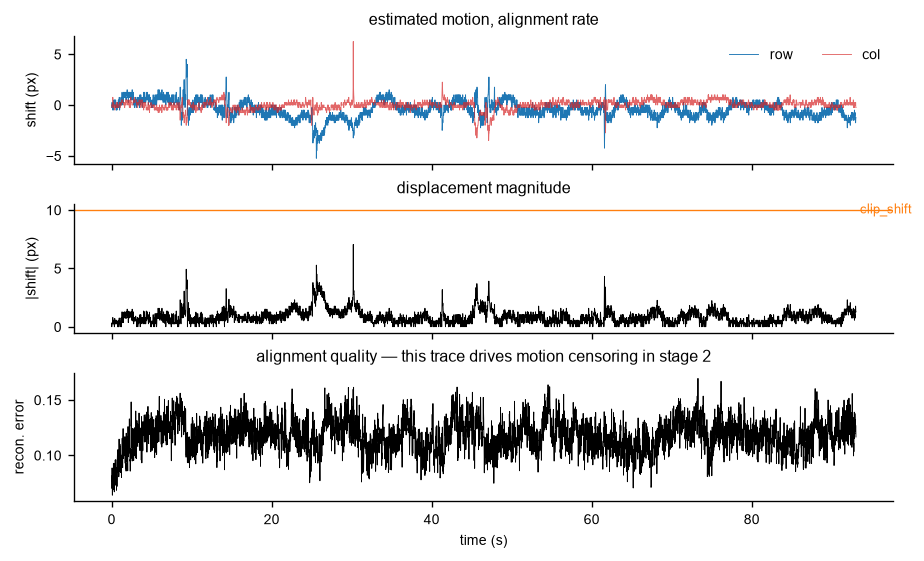

In [6]:
adata = store.load_alignment_data(1)
motion_mag = np.hypot(adata.motion_ds_r, adata.motion_ds_c)
t_ds = np.arange(len(adata.motion_ds_r)) / adata.align_hz

print(f"alignment rate      {adata.align_hz:.2f} Hz  (= {1/adata.frame_time:.1f} / {2**DS_TIME})")
print(f"motion, downsampled {len(adata.motion_ds_r)} samples")
print(f"motion, full rate   {len(adata.motion_r)} samples (PCHIP upsampled)")
print(f"displacement        median {np.nanmedian(motion_mag):.2f} px, "
      f"95th {np.nanpercentile(motion_mag, 95):.2f} px, max {np.nanmax(motion_mag):.2f} px")

fig, axes = plt.subplots(3, 1, figsize=(7.0, 4.2), sharex=True, constrained_layout=True)
axes[0].plot(t_ds, adata.motion_ds_r, color="tab:blue", lw=0.5, label="row")
axes[0].plot(t_ds, adata.motion_ds_c, color="tab:red", lw=0.5, alpha=0.7, label="col")
axes[0].set_ylabel("shift (px)")
axes[0].set_title("estimated motion, alignment rate")
axes[0].legend(loc="upper right", ncols=2)

axes[1].plot(t_ds, motion_mag, color="k", lw=0.5)
axes[1].axhline(reg_cfg.clip_shift, color="tab:orange", lw=0.75)
axes[1].text(t_ds[-1], reg_cfg.clip_shift, " clip_shift", va="center", fontsize=7,
             color="tab:orange")
axes[1].set_ylabel("|shift| (px)")
axes[1].set_title("displacement magnitude")

axes[2].plot(t_ds, adata.rec_neg_err, color="k", lw=0.5)
axes[2].set_ylabel("recon. error")
axes[2].set_xlabel("time (s)")
axes[2].set_title("alignment quality — this trace drives motion censoring in stage 2")
plt.show()

input FOV         46 x 128
registered canvas 55 x 137  <- data dependent, see section 7
registered_ds     (55, 137, 10000)
registered_raw    (55, 137, 80000)

frames flagged as motion-corrupted: 0 / 5000 (0.0 %)


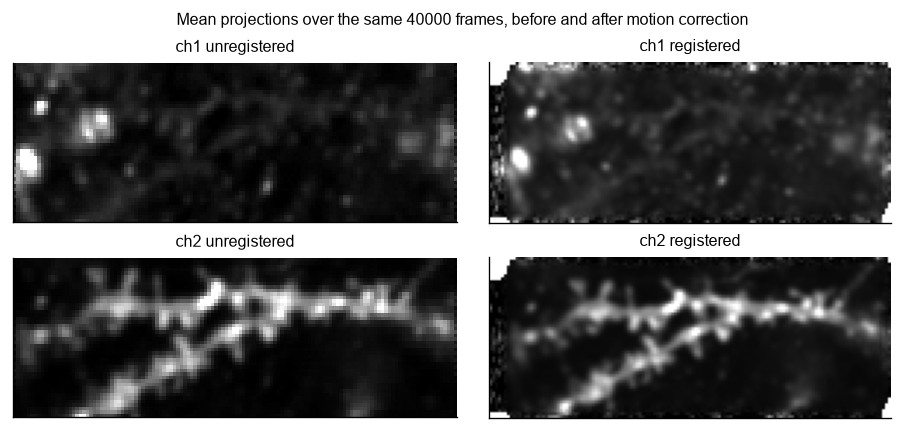

median frame-to-average correlation, unregistered: 0.5906
median frame-to-average correlation, registered:   0.7457

Registration buys 26 % on this metric even though the median displacement
is only 0.75 px, because most of what it removes is fast jitter
within the 8-frame alignment bin rather than slow drift. The mean projections
above barely change; the frame-by-frame data that stage 2 actually reads does.


In [7]:
from subcell.config import ExtractionConfig
from subcell.pipeline.runner import detect_motion_frames

reg_ds = store.load_registered_ds(1)
n_ds = reg_ds.shape[2] // n_ch
# stored channel-interleaved along the last axis: [t0c0, t0c1, t1c0, ...]
movie_ds = reg_ds.reshape(reg_ds.shape[0], reg_ds.shape[1], n_ds, n_ch).transpose(0, 1, 3, 2)
mean_reg = np.nanmean(movie_ds, axis=3)

# The registered canvas is LARGER than the input FOV: frames are pasted onto a maxshift-padded
# canvas, then rows/cols that are out of bounds for every frame are cropped back off.
print(f"input FOV         {Ad.shape[0]-REMOVE_LINES} x {Ad.shape[1]}")
print(f"registered canvas {reg_ds.shape[0]} x {reg_ds.shape[1]}  <- data dependent, see section 7")
print(f"registered_ds     {reg_ds.shape}")
print(f"registered_raw    {store.root['trials/trial_001/registered_raw'].shape}")

discard = detect_motion_frames(adata, ExtractionConfig())
print(f"\nframes flagged as motion-corrupted: {discard.sum()} / {discard.size} "
      f"({100*discard.mean():.1f} %)")

# Unregistered mean over exactly the same frames, accumulated in chunks so the
# comparison is not confounded by averaging different numbers of frames.
acc = np.zeros((Ad.shape[0] - REMOVE_LINES, Ad.shape[1], n_ch), dtype=np.float64)
for s in range(0, n_use, 4000):
    acc += Ad[REMOVE_LINES:, :, :, s:min(s + 4000, n_use)].sum(axis=3, dtype=np.float64)
raw_mean = (acc / n_use).astype(np.float32)


fig, axes = plt.subplots(n_ch, 2, figsize=(7.0, 1.6 * n_ch), constrained_layout=True)
for ch in range(n_ch):
    for j, (img, name) in enumerate([(raw_mean[:, :, ch], "unregistered"),
                                     (mean_reg[:, :, ch], "registered")]):
        ax = axes[ch, j]
        ax.imshow(img, cmap="gray",
                  vmin=np.nanpercentile(img, 1), vmax=np.nanpercentile(img, 99.5))
        ax.set_title(f"ch{ch+1} {name}")
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle(f"Mean projections over the same {n_use} frames, before and after "
             f"motion correction", fontsize=9)
plt.show()


def frame_stability(stack, n_sample=300):
    # Median correlation between single frames and the frame-average. This is what
    # registration is actually for. A gradient-based "sharpness" would be unfair
    # here: the registered image is resampled with sub-pixel interpolation onto a
    # larger canvas, which low-pass filters it regardless of how well it aligned.
    mean = np.nanmean(stack, axis=2)
    idx = np.linspace(0, stack.shape[2] - 1, min(n_sample, stack.shape[2])).astype(int)
    out = []
    for t in idx:
        f = stack[:, :, t]
        ok = np.isfinite(f) & np.isfinite(mean)
        if ok.sum() < 100:
            continue
        a = f[ok] - f[ok].mean()
        b = mean[ok] - mean[ok].mean()
        out.append(float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b))))
    return float(np.median(out))


# Same 8-frame temporal binning as registration uses, channels summed, before vs after.
starts = np.linspace(0, n_use - 2 ** DS_TIME, 300).astype(int)
raw_stack = np.stack(
    [Ad[REMOVE_LINES:, :, :, s:s + 2 ** DS_TIME].sum(axis=(2, 3), dtype=np.float32)
     for s in starts], axis=2)
reg_stack = movie_ds.sum(axis=2)[:, :, np.linspace(0, n_ds - 1, 300).astype(int)]

stab_raw, stab_reg = frame_stability(raw_stack), frame_stability(reg_stack)
print(f"median frame-to-average correlation, unregistered: {stab_raw:.4f}")
print(f"median frame-to-average correlation, registered:   {stab_reg:.4f}")
print(f"\nRegistration buys {100*(stab_reg-stab_raw)/stab_raw:.0f} % on this metric even "
      f"though the median displacement\nis only {np.nanmedian(motion_mag):.2f} px, because "
      f"most of what it removes is fast jitter\nwithin the 8-frame alignment bin rather "
      f"than slow drift. The mean projections\nabove barely change; the frame-by-frame "
      f"data that stage 2 actually reads does.")
del raw_stack, reg_stack

---
## 4. Stage 2 — which channel carries the signal?

`localize_sources` is the detector: baseline-subtract and noise-normalise each pixel's time
series, run a causal exponential matched filter at `tau_s`, apply a difference-of-Gaussians at
`sigma_px`, then spatiotemporal non-maximum suppression. The **activity image** is the sum of
squared surviving peaks per pixel — it is the map everything downstream is picked from.

Running it on both channels is the cheapest honest way to decide which one is glutamate.

10:53:36 INFO    subcell.extraction.localize: Localized 12 sources


subcell ch1 (ScanImage ch2):  12 sources, activity p99 = 5.75e-05   [18.2 s]


10:53:54 INFO    subcell.extraction.localize: Localized 39 sources


subcell ch2 (ScanImage ch4):  39 sources, activity p99 = 0.00022   [17.3 s]

-> using activity_channel = 2 (ScanImage ch4)


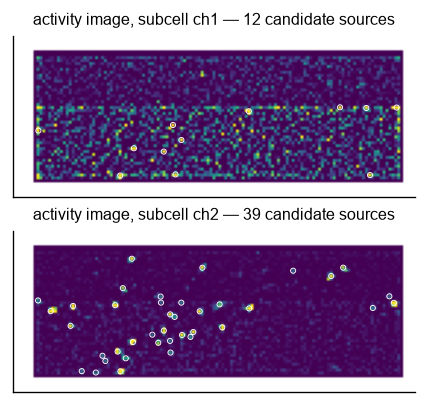

In [8]:
from subcell.extraction.localize import localize_sources

act_by_ch, peaks_by_ch = {}, {}
for ch in range(1, n_ch + 1):
    cfg = ExtractionConfig(activity_channel=ch, device=DEVICE)
    t0 = time.perf_counter()
    act, pk = localize_sources(movie_ds[:, :, ch - 1, :], cfg, adata.align_hz)
    act_by_ch[ch], peaks_by_ch[ch] = act, pk
    print(f"subcell ch{ch} (ScanImage ch{meta.channel_save[ch-1]}): "
          f"{len(pk.row):>3d} sources, activity p99 = {np.nanpercentile(act, 99):.3g}   "
          f"[{time.perf_counter()-t0:.1f} s]")

ACTIVITY_CH = max(act_by_ch, key=lambda c: len(peaks_by_ch[c].row))
print(f"\n-> using activity_channel = {ACTIVITY_CH} "
      f"(ScanImage ch{meta.channel_save[ACTIVITY_CH-1]})")

fig, axes = plt.subplots(n_ch, 1, figsize=(7.0, 1.5 * n_ch), constrained_layout=True)
for ch in range(1, n_ch + 1):
    ax = axes[ch - 1]
    a = act_by_ch[ch]
    ax.imshow(a, cmap="viridis", vmin=0, vmax=np.nanpercentile(a, 99.5))
    pk = peaks_by_ch[ch]
    ax.scatter(pk.col, pk.row, s=8, facecolors="none", edgecolors="w", linewidths=0.5)
    ax.set_title(f"activity image, subcell ch{ch} — {len(pk.row)} candidate sources")
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

---
## 5. Stage 2 — the full extraction

`run_extraction` chains the four steps. With a single trial, step 2 (cross-trial alignment) is a
no-op that still runs and reports a correlation of 1.0.

Step 4 is the expensive one. It splits the field of view into independent **subproblems** —
connected clusters of sources whose PSF-dilated footprints touch — and solves each with L-BFGS on
GPU or CPU, streaming only the selected pixels out of `registered_raw` (`block_size` frames at a
time). Concurrency is capped by available RAM, `n_parallel_workers`, and `cpu_count // 4`.

In [9]:
from subcell.pipeline.runner import run_extraction

ext_cfg = ExtractionConfig(
    microscope="bergamo",
    activity_channel=ACTIVITY_CH,
    sigma_px=1.33,             # PSF sigma, px
    dXY=3,                     # source radius, px -> sel_radius = ceil(2 * dXY) = 6
    tau_s=0.03,                # indicator decay -> ~13 frames at 430 Hz
    denoise_window_s=0.2,
    baseline_window_glu_s=4.0,
    max_synapse_density=0.01,  # at most 1 source per 100 valid pixels
    nmf_iter=2,
    motion_thresh=2.5,         # threshold on the detrended reconstruction-error trace
    nan_thresh=0.33,           # a pixel NaN in >33 % of frames is dropped
    block_size=600,
    n_parallel_workers=4,
    device=DEVICE,
)

t0 = time.perf_counter()
run_extraction(trial_table, ext_cfg, store, device=None)
ext_s = time.perf_counter() - t0
print(f"\nextraction: {ext_s:.1f} s")

10:53:54 INFO    subcell._utils.torch_helpers: Using device: cpu


10:53:54 INFO    subcell.pipeline.runner: Step 1: Per-trial source localization...


10:54:12 INFO    subcell.extraction.localize: Localized 39 sources


10:54:12 INFO    subcell.pipeline.runner: Step 2: Cross-trial alignment...


10:54:12 INFO    subcell.registration.template: Building cross-trial template from 1 trials


...

10:54:12 INFO    subcell.pipeline.runner: Step 4: High-resolution signal extraction...


10:54:12 INFO    subcell.pipeline.runner: Extracting trial 1...


10:54:32 INFO    subcell.io.zarr_store: Saved experiment summary with 34 sources


10:54:32 INFO    subcell.pipeline.runner: Extraction complete: 34 sources across 1 trials



extraction: 38.2 s


34 sources over 40000 frames at 429.9 Hz
selected pixels: 2362 of 7535 (31.3 % of the canvas)
SNR: median 5.26, range 2.87-918.03


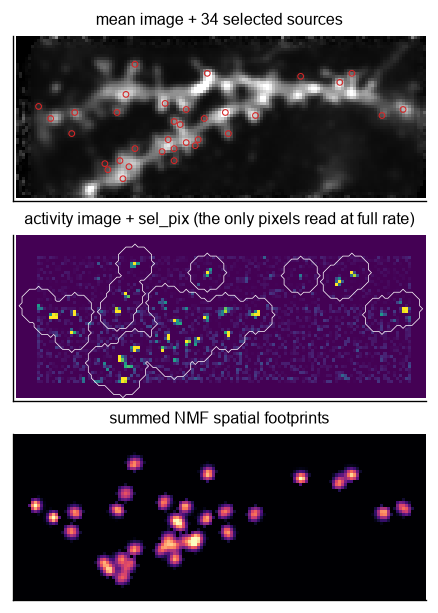

In [10]:
summ = store.root["summary"]
ext = store.root["trials/trial_001/extraction"]

src_r = np.array(summ["sources/locations_r"])
src_c = np.array(summ["sources/locations_c"])
sel_pix = np.array(summ["sources/sel_pix"])
act_img = np.array(summ["activity_image"])
mean_img = np.array(summ["mean_image"])

footprints = np.array(ext["footprints"])   # (n_selected_pixels, n_sources)
events = np.array(ext["events"])           # (n_sources, n_frames), sparse inferred events
denoised = np.array(ext["denoised"])       # events convolved with the decay kernel
ls = np.array(ext["ls"])                   # unconstrained least-squares estimate
F0 = np.array(ext["F0"])                   # per-source baseline fluorescence
SNR = np.array(ext["SNR"])
n_sources = len(src_r)

print(f"{n_sources} sources over {events.shape[1]} frames at {1/adata.frame_time:.1f} Hz")
print(f"selected pixels: {sel_pix.sum()} of {sel_pix.size} "
      f"({100*sel_pix.mean():.1f} % of the canvas)")
print(f"SNR: median {np.nanmedian(SNR):.2f}, range {np.nanmin(SNR):.2f}-{np.nanmax(SNR):.2f}")

# Paint the footprint matrix back onto the canvas.
foot_img = np.zeros(sel_pix.shape, dtype=np.float32)
foot_img[sel_pix] = np.nansum(footprints, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(7.0, 4.6), constrained_layout=True)
ax = axes[0]
mimg = mean_img[:, :, ACTIVITY_CH - 1]
ax.imshow(mimg, cmap="gray", vmin=np.nanpercentile(mimg, 1), vmax=np.nanpercentile(mimg, 99.5))
ax.scatter(src_c, src_r, s=10, facecolors="none", edgecolors="tab:red", linewidths=0.6)
ax.set_title(f"mean image + {n_sources} selected sources")

ax = axes[1]
ax.imshow(act_img, cmap="viridis", vmin=0, vmax=np.nanpercentile(act_img, 99.5))
ax.contour(sel_pix, levels=[0.5], colors="w", linewidths=0.4)
ax.set_title("activity image + sel_pix (the only pixels read at full rate)")

ax = axes[2]
hi = np.nanpercentile(foot_img[foot_img > 0], 99) if np.any(foot_img > 0) else 1.0
ax.imshow(foot_img, cmap="magma", vmin=0, vmax=hi)
ax.set_title("summed NMF spatial footprints")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

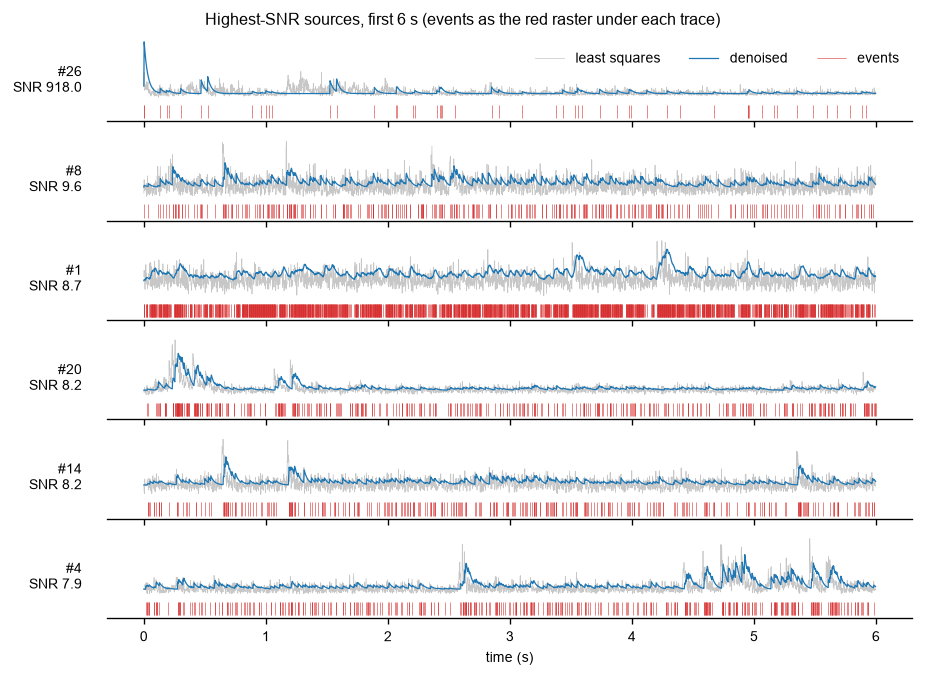

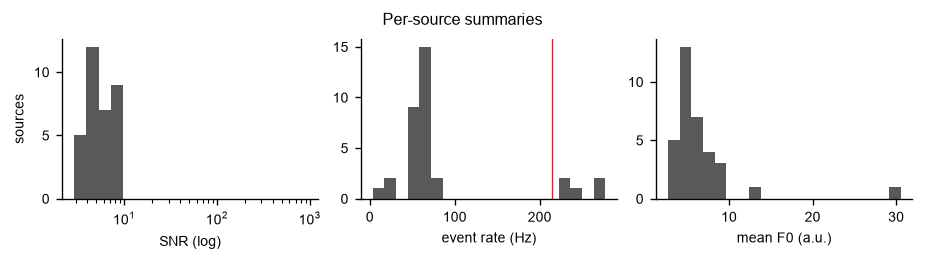

SNR spans 2.9 to 918.0 - the top of that range is a
degenerate fit, not a real measurement, so treat SNR as a ranking rather than a
calibrated quantity.

The red line marks half the frame rate (215 Hz). Sources
above it are firing on most frames, i.e. the solver never found a sparse
solution for them - a useful filter when deciding which sources to keep.


In [11]:
order = np.argsort(np.nan_to_num(SNR))[::-1]
show = order[:6]
t_full = np.arange(events.shape[1]) * adata.frame_time
win = slice(0, min(events.shape[1], int(6 / adata.frame_time)))   # first 6 s
t_win = t_full[win]

# `events` is a sparse spike train and `denoised` is that train convolved with the
# decay kernel, so they live on very different scales. Plotting the traces together
# and the events as a raster strip underneath keeps both readable.
fig, axes = plt.subplots(len(show), 1, figsize=(7.0, 0.85 * len(show)),
                         sharex=True, constrained_layout=True)
for ax, i in zip(axes, show):
    ax.plot(t_win, ls[i, win], color="0.78", lw=0.4, label="least squares")
    ax.plot(t_win, denoised[i, win], color="tab:blue", lw=0.7, label="denoised")
    lo, hi = ax.get_ylim()
    strip = lo - 0.30 * (hi - lo)
    ev = np.nan_to_num(events[i, win])
    hit = np.flatnonzero(ev > 0)
    ax.vlines(t_win[hit], strip, strip + 0.22 * (hi - lo),
              color="tab:red", lw=0.3, label="events")
    ax.set_ylim(strip - 0.05 * (hi - lo), hi)
    ax.set_ylabel(f"#{i}\nSNR {SNR[i]:.1f}", rotation=0, ha="right", va="center",
                  labelpad=14)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
axes[0].legend(loc="upper right", ncols=3)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Highest-SNR sources, first 6 s (events as the red raster under each trace)",
             fontsize=9)
plt.show()

snr_ok = SNR[np.isfinite(SNR) & (SNR > 0)]
rate = np.nansum(events > 0, axis=1) / (events.shape[1] * adata.frame_time)

fig, axes = plt.subplots(1, 3, figsize=(7.0, 1.9), constrained_layout=True)
axes[0].hist(snr_ok, bins=np.logspace(np.log10(snr_ok.min()), np.log10(snr_ok.max()), 20),
             color="0.35")
axes[0].set_xscale("log")
axes[0].set_xlabel("SNR (log)")
axes[0].set_ylabel("sources")
axes[1].hist(rate, bins=20, color="0.35")
axes[1].axvline(1 / adata.frame_time / 2, color="tab:red", lw=0.75)
axes[1].set_xlabel("event rate (Hz)")
axes[2].hist(np.nanmean(F0, axis=1), bins=20, color="0.35")
axes[2].set_xlabel("mean F0 (a.u.)")
fig.suptitle("Per-source summaries", fontsize=9)
plt.show()

print(f"SNR spans {snr_ok.min():.1f} to {snr_ok.max():.1f} - the top of that range is a")
print("degenerate fit, not a real measurement, so treat SNR as a ranking rather than a")
print("calibrated quantity.")
print(f"\nThe red line marks half the frame rate ({1/adata.frame_time/2:.0f} Hz). Sources")
print("above it are firing on most frames, i.e. the solver never found a sparse")
print("solution for them - a useful filter when deciding which sources to keep.")

---
## 6. What the output store looks like

Everything is one Zarr v2 directory store, zstd-compressed. Nothing else is written — no TIFFs,
no `.mat`, no CSV. `subcell.visualization.ExtractionViewer` (`load_zarr`) reads this layout
directly, and `load_mat` reads the MATLAB equivalent.

In [12]:
import zarr

DOC = {
    "summary/mean_image": "cross-trial mean, (H, W, C)",
    "summary/activity_image": "cross-trial mean activity image, (H, W)",
    "summary/valid_trials": "positions of trials that passed cross-trial QC",
    "summary/sources/locations_r": "source row, sub-pixel refined",
    "summary/sources/locations_c": "source col, sub-pixel refined",
    "summary/sources/sel_pix": "union of per-source pixel disks, (H, W) bool",
    "summary/trial_alignment/offsets": "per-trial (row, col) shift onto the common frame",
    "summary/trial_alignment/corr_coeffs": "per-trial correlation with the cross-trial template",
    "registered_ds": "8x temporally downsampled registered movie, channel-interleaved",
    "registered_raw": "full-rate registered movie, channel-interleaved (the big one)",
    "motion_r": "row shift per raw frame",
    "motion_c": "col shift per raw frame",
    "motion_ds_r": "row shift per downsampled frame",
    "motion_ds_c": "col shift per downsampled frame",
    "rec_neg_err": "per-downsampled-frame reconstruction error (QC + censoring)",
    "ch1_8bit": "sqrt-scaled 8-bit preview",
    "ch2_8bit": "sqrt-scaled 8-bit preview",
    "mean_image": "per-trial mean, (H, W, C)",
    "activity_image": "per-trial activity image, (H, W)",
    "footprints": "NMF spatial weights, (n_sel_pixels, n_sources)",
    "events": "inferred non-negative events, (n_sources, n_frames)",
    "denoised": "events convolved with the exp(-t/tau) kernel",
    "ls": "unconstrained least-squares trace",
    "F0": "per-source baseline fluorescence, (n_sources, n_frames)",
    "SNR": "per-source signal-to-noise, (n_sources,)",
    "discard_frames": "motion-censored frames, (n_frames,) bool",
}


def walk(group, prefix="", depth=0):
    for name in sorted(group.keys()):
        item = group[name]
        path = f"{prefix}{name}"
        pad = "  " * depth
        if isinstance(item, zarr.Group):
            print(f"{pad}{name}/")
            walk(item, f"{path}/", depth + 1)
        else:
            doc = DOC.get(path, DOC.get(name, ""))
            print(f"{pad}{name:<16} {str(item.shape):<22} {str(item.dtype):<9} {doc}")


walk(store.root)

nbytes = sum(f.stat().st_size for f in ZARR.rglob("*") if f.is_file())
print(f"\nstore on disk: {nbytes/1e9:.2f} GB for {n_use} frames")

summary/
  activity_image   (55, 137)              float32   cross-trial mean activity image, (H, W)
  mean_image       (55, 137, 2)           float32   cross-trial mean, (H, W, C)
  sources/
    locations_c      (34,)                  float64   source col, sub-pixel refined
    locations_r      (34,)                  float64   source row, sub-pixel refined
    sel_pix          (55, 137)              bool      union of per-source pixel disks, (H, W) bool
  trial_alignment/
    corr_coeffs      (1,)                   float64   per-trial correlation with the cross-trial template
    offsets          (2, 1)                 float64   per-trial (row, col) shift onto the common frame
  valid_trials     (1,)                   int32     positions of trials that passed cross-trial QC
trials/
  trial_001/
    activity_image   (55, 137)              float32   per-trial activity image, (H, W)
    alignment/
      motion_c         (40000,)               float64   col shift per raw frame
      motio

---
## 7. Cost model and the sharp edges

The cell below turns this run into per-frame numbers to extrapolate from. Two things dominate
everything else:

* **`save_full_resolution` is the storage story.** `registered_ds` is negligible;
  `registered_raw` is `H x W x frames x channels x 4 bytes` before compression. Even at this
  tiny 50 x 128 FOV that is tens of GB for a full session of trials.
* **GPU barely helps here.** `dft_registration` only runs on GPU when `rows * cols > 500 * 500`;
  at 46 x 128 the registration loop stays on CPU whatever `device` says. Only the NMF solve moves
  to CUDA. And `n_workers > 1` spawns a *process* pool over trials, which forces CPU for everything.

In [13]:
raw_arr = store.root["trials/trial_001/registered_raw"]
full_frames = meta.num_frames

print(f"measured on {n_use} frames ({n_use*meta.frame_time:.0f} s of recording), device={DEVICE}")
print(f"  registration   {reg_s:8.1f} s   ({reg_s/n_use*1e3:.3f} ms/frame)")
print(f"  extraction     {ext_s:8.1f} s   ({ext_s/n_sources:.2f} s/source, {n_sources} sources)")
print(f"  store          {nbytes/1e9:8.2f} GB  ({nbytes/n_use/1e3:.2f} kB/frame)")
print(f"\nextrapolated to the whole {full_frames:,}-frame file "
      f"({full_frames*meta.frame_time:.0f} s):")
print(f"  registration   {reg_s/n_use*full_frames/60:8.1f} min")
print(f"  extraction     {ext_s/n_use*full_frames/60:8.1f} min   (NMF is ~linear in frames)")
print(f"  store          {nbytes/n_use*full_frames/1e9:8.1f} GB")
print(f"\nregistered_raw uncompressed would be {np.prod(raw_arr.shape)*4/1e9:.2f} GB; "
      f"zstd gets the whole store to {nbytes/1e9:.2f} GB.")

measured on 40000 frames (93 s of recording), device=cpu
  registration       23.0 s   (0.575 ms/frame)
  extraction         38.2 s   (1.12 s/source, 34 sources)
  store              1.76 GB  (44.01 kB/frame)

extrapolated to the whole 168,533-frame file (392 s):
  registration        1.6 min
  extraction          2.7 min   (NMF is ~linear in frames)
  store               7.4 GB

registered_raw uncompressed would be 2.41 GB; zstd gets the whole store to 1.76 GB.


### The multi-trial path does not currently work

This is the most important thing to know before treating `subcell` as a drop-in pipeline.

Every trial is registered onto its **own** canvas: frames are pasted onto a `maxshift`-padded
buffer, then `_compute_nan_borders` crops the rows and columns that were out of bounds for
*every* frame of *that* trial. The crop therefore depends on that trial's motion range, so **two
trials with different motion produce differently shaped outputs**.

`run_extraction` then stacks them:

```python
h, w, n_ch = mean_images[valid_indices[0]].shape
mean_stack = np.full((h, w, n_ch, n_trials), np.nan, ...)
for i in valid_indices:
    mean_stack[:, :, :, i] = mean_images[i]      # <- ValueError as soon as shapes differ
```

The cell below reproduces it on two windows of this recording. It registers downsampled-only (no
`registered_raw`), so it is cheap.

In [14]:
probe_zarr = OUT_DIR / "_multitrial_probe.zarr"
probe_store = ExperimentStore(probe_zarr)
probe_cfg = RegistrationConfig(remove_lines=REMOVE_LINES, ds_time=DS_TIME, n_workers=1,
                               init_frames=1000, save_full_resolution=False,
                               overwrite_existing=True)
probe_tt = TrialTable(
    directory=str(DATA_DIR),
    entries=[TrialEntry(filename=f"window_{i+1}", trial_index=i + 1, epoch=1)
             for i in range(2)],
)

# Two 8k-frame windows, chosen because the sample drifted very differently in each.
for i, start in enumerate((0, 40_000)):
    blk = np.asarray(Ad[:, :, :, start:start + 8_000])
    pg = np.transpose(blk, (0, 1, 3, 2)).reshape(blk.shape[0], blk.shape[1], -1)
    del blk
    one = TrialTable(
        directory=str(DATA_DIR),
        entries=[TrialEntry(filename=f"window_{i+1}", trial_index=i + 1, epoch=1)],
    )
    register_bergamo(one, probe_cfg, probe_store, device=DEVICE, raw_data=pg, metadata=meta)
    del pg

print("\nper-trial registered canvases:")
for i in (1, 2):
    s = probe_store.root[f"trials/trial_{i:03d}/registered_ds"].shape
    a = probe_store.load_alignment_data(i)
    print(f"  trial {i}: {s[0]} x {s[1]}   row motion "
          f"[{np.nanmin(a.motion_ds_r):+.2f}, {np.nanmax(a.motion_ds_r):+.2f}]  "
          f"col motion [{np.nanmin(a.motion_ds_c):+.2f}, {np.nanmax(a.motion_ds_c):+.2f}] px")

try:
    run_extraction(probe_tt, ExtractionConfig(activity_channel=ACTIVITY_CH, device=DEVICE),
                   probe_store, device=None)
    print("\nno error — these two windows happened to crop to the same size")
except ValueError as exc:
    print(f"\nrun_extraction raised: {type(exc).__name__}: {exc}")

10:54:33 INFO    subcell.io.zarr_store: Opened Zarr store at C:\Users\loson\data\adrian\iGluSnFR4f_example_data\subcell_demo\_multitrial_probe.zarr


10:54:33 INFO    subcell._utils.parallel: Using 1 workers (requested=1, memory-limited=1, trials=1)


10:54:33 INFO    subcell.registration.bergamo: Registering 1 trials with 1 workers


10:54:33 INFO    subcell.registration.bergamo: Aligning trial 1: window_1


10:54:33 INFO    subcell.registration.bergamo: Using pre-loaded data, skipping TIFF read


...

10:54:41 INFO    subcell.pipeline.runner: Step 1: Per-trial source localization...



per-trial registered canvases:
  trial 1: 52 x 130   row motion [-2.00, +4.50]  col motion [-2.00, +1.25] px
  trial 2: 56 x 144   row motion [-4.50, +6.50]  col motion [-14.25, +3.25] px


10:54:45 INFO    subcell.extraction.localize: Localized 33 sources


10:54:48 INFO    subcell.extraction.localize: Localized 30 sources



run_extraction raised: ValueError: could not broadcast input array from shape (56,144,2) into shape (52,130,2)


**What a fix has to touch.** Making trials share a canvas is not a one-liner, because the crop
offsets are never recorded and step 4 indexes `registered_raw` with a mask built in canvas
coordinates:

```python
Y_sel = store.load_registered_raw_pixels(entry.trial_index, sel_pix_union, ...)
```

so `sel_pix_union` and every trial's stored movie must already live in the same frame. Either
registration stops cropping per trial (write everyone onto the `maxshift`-padded canvas), or the
crop offsets get persisted alongside `alignment/` and stage 2 maps in and out of them. The first
is much simpler and costs only some NaN padding.

Note also that step 4 ignores the per-trial shift step 2 estimated when it reads pixels — it
relies on `sel_radius = ceil(2 * dXY) = 6 px` being wide enough to absorb it. That is fine for the
+/-5 px `cross_trial_maxshift` default, but it is an assumption rather than a guarantee.

*(A separate off-by-one in the same function — `store.has_registered_raw()` was called with the
0-based list position instead of the 1-based `trial_index`, so extraction always reported "no
trial has full-resolution registered data" — is fixed in this working tree. Without that fix
nothing past step 3 runs at all, single trial included.)*

---
## 8. Notes for wiring this into `mbo_utilities`

The plumbing already exists. `pyproject.toml` declares

```toml
[project.entry-points."mbo_utilities.pipelines"]
subcell = "subcell.mbo:SubcellPipelineWidget"
```

and `subcell/mbo.py` provides both the imgui widget and the worker `task_subcell(args, logger)`,
which does `imread -> array_trial_source -> trial_table_from_array -> register_bergamo(source=...)
-> run_extraction`. `axes_consumed` declares `T: all`, `Z: none`, `C: select-one`.

Things to settle before relying on it:

1. **Flyback.** Route C never applies `remove_lines`. `mbo_utilities` already knows the count
   (`metadata["num_fly_to_lines"]`) — decide whether subcell crops it or the array does, and make
   one of them actually do it.
2. **Multi-trial.** `task_subcell` calls `run_extraction` over however many trials
   `frames_per_file` yields. More than one file hits section 7's `ValueError`. Single-file
   sessions work today.
3. **Trial boundaries.** They come only from `frames_per_file`. If trials are epochs inside one
   file rather than separate files, `ArrayTrialSource.trial_slices` has to be set by hand — it is
   a plain dataclass field, so that part is easy.
4. **Memory.** `ArrayTrialSource.read_trial` materialises a whole trial:
   `frames x channels x H x W x itemsize`. This recording is 4.3 GB as int16, and
   `register_bergamo` then holds that plus its own working arrays.
5. **Channel semantics.** `activity_channel` is 1-based into the saved-channel order, and
   `applies_to` only checks `shape[2] == 1` (single plane). Nothing verifies the chosen channel is
   the glutamate one.
6. **Device.** `n_workers > 1` forces CPU (process pool), and the registration DFT only uses GPU
   above 500x500 px. For Bergamo FOVs, CPU with `n_workers=1` on route C is the realistic
   configuration, and section 7 shows that is fast enough.

In [15]:
reader.close()
print("done")

done


In [1]:
%load_ext autoreload
%autoreload 2

from subcell.visualization import ExtractionViewer

In [5]:
import os

from pathlib import Path

viewer = ExtractionViewer()

if ZARR.exists():
    viewer.load(ZARR)

viewer.show()

11:37:35 INFO    subcell.visualization._loaders: Loaded Zarr: 1 trials, 34 sources, 429.9 Hz


Column(sizing_mode='stretch_width')
    [0] Markdown(str, sizing_mode='stretch_width')
    [1] Row(sizing_mode='stretch_width')
        [0] Column(sizing_mode='fixed', width=100)
            [0] Button(button_type='primary', color='primary', label='Browse...', name='Browse...', width=80)
            [1] Select(label='Channel', name='Channel', options={'Ch 1': 0, 'Ch 2': 1}, value=0, width=80)
            [2] Select(label='Trial', name='Trial', options={'Trial 1': 1}, value=1, width=80)
            [3] Select(label='Signal', name='Signal', options=['denoised', 'events', ...], value='denoised', width=80)
            [4] Toggle(label='Initial footprints', name='Initial footprints', visible=False, width=80)
            [5] FloatSlider(end=918.030517578125, label='Min SNR', name='Min SNR', step=0.05)
            [6] MultiSelect(label='Sources', name='Sources', options={'0 (7.56)': 0, ...}, size=13, width=80)
        [1] Column(sizing_mode='stretch_width')
            [0] Bokeh(figure, sizing_mode='stretch_width')
            [1] Bokeh(figure, height=280, sizing_mode='stretch_width')